<a href="https://colab.research.google.com/github/pavel021998-source/Python_analysis/blob/main/Store_Sales_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Python/
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker





places = pd.read_csv("countries.csv")
product = pd.read_csv("products.csv")
event = pd.read_csv("events.csv")
places.info()
product.info()
event.info()



Mounted at /content/drive
/content/drive/MyDrive/Python
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order

In [ ]:
# Overview
places.describe()
product.describe()
event.describe()

,Order ID,Product ID,Units Sold,Unit Price,Unit Cost
count,1.330000e+03,1330.000000,1328.000000,1330.000000,1330.000000
mean,5.412048e+08,5788.096241,4952.201807,264.893541,187.246812
std,2.573882e+08,2820.728878,2905.198996,217.323460,176.158873
min,1.006406e+08,1270.000000,2.000000,9.330000,6.920000
25%,3.190004e+08,3127.000000,2356.750000,81.730000,35.840000
50%,5.387164e+08,5988.000000,4962.000000,154.060000,97.440000
75%,7.544628e+08,8681.000000,7459.500000,437.200000,263.330000
max,9.998797e+08,8969.000000,9999.000000,668.270000,524.960000


In [ ]:
# Checking empty  values and spaces in words

event["Order Date"] = pd.to_datetime(event["Order Date"], format="%m/%d/%Y")
event["Ship Date"] = pd.to_datetime(event["Ship Date"], format="%m/%d/%Y")

events_cleaned = event.dropna()
places_cleaned = places.dropna()
products_cleaned = product.dropna()

events_cleaned = events_cleaned.apply(lambda x:
                                      x.str.strip() if x.dtype == "object" else x)
places_cleaned = places_cleaned.apply(lambda x:
                                      x.str.strip() if x.dtype == "object" else x)
products_cleaned = products_cleaned.apply(lambda x:
                                      x.str.strip() if x.dtype == "object" else x)

#Sales Channel online uppercase
events_cleaned['Sales Channel'] = events_cleaned['Sales Channel'].str.capitalize()

# Removing duplicates
places_cleaned = places_cleaned.drop_duplicates()
events_cleaned = events_cleaned.drop_duplicates()
products_cleaned = products_cleaned.drop_duplicates()



# Renamed product [id] to product[Product ID] for future merger
products_cleaned = products_cleaned.rename(columns={"id": "Product ID"})
places_cleaned = places_cleaned.rename(columns={"alpha-3": "Country Code"})
places_cleaned = places_cleaned.rename(columns={"name":"Country name"})

print(events_cleaned)


       Order ID Order Date  Ship Date Order Priority Country Code  Product ID  \
0     100640618 2014-10-08 2014-10-18              M          NOR        2103   
1     100983083 2016-08-11 2016-08-11              C          SRB        2103   
3     102230632 2017-05-13 2017-06-13              L          MNE        2455   
4     103435266 2012-08-11 2012-09-18              H          SRB        1270   
5     103450715 2015-03-15 2015-04-18              H          SVK        8681   
...         ...        ...        ...            ...          ...         ...   
1325  994504153 2017-01-10 2017-01-13              M          SWE        4594   
1326  994978797 2014-12-05 2015-01-02              H          ITA        1270   
1327  996754205 2010-09-20 2010-09-22              L          RUS        7331   
1328  998043382 2010-06-15 2010-07-03              H          MLT        8293   
1329  999879729 2012-03-31 2012-05-06              M          ALB        7940   

     Sales Channel  Units S

In [ ]:
# Joining dataframes

products_cleaned.head()

left_join = pd.merge(events_cleaned,products_cleaned, on = "Product ID", how ="left")
events_joined = pd.merge(left_join,places_cleaned, on = "Country Code", how ="left")

joined = events_joined.drop(columns = ["Product ID","alpha-2","sub-region","Country Code"])

print(joined)



       Order ID Order Date  Ship Date Order Priority Sales Channel  \
0     100640618 2014-10-08 2014-10-18              M        Online   
1     100983083 2016-08-11 2016-08-11              C       Offline   
2     102230632 2017-05-13 2017-06-13              L        Online   
3     103435266 2012-08-11 2012-09-18              H       Offline   
4     103450715 2015-03-15 2015-04-18              H        Online   
...         ...        ...        ...            ...           ...   
1241  994504153 2017-01-10 2017-01-13              M        Online   
1242  994978797 2014-12-05 2015-01-02              H       Offline   
1243  996754205 2010-09-20 2010-09-22              L       Offline   
1244  998043382 2010-06-15 2010-07-03              H        Online   
1245  999879729 2012-03-31 2012-05-06              M       Offline   

      Units Sold  Unit Price  Unit Cost        item_type Country name  region  
0          650.0      205.70     117.11           Cereal       Norway  Europe  

In [ ]:

# Main metrics
orders_number = joined["Order ID"].count() - 1
print(f"Number of orders: {orders_number}")

average_order = joined["Units Sold"].median()
print(f"Average amount of order: ${average_order}")

min_order = joined["Units Sold"].min()
print(f"Minimum amount of order: ${min_order}")

max_order = joined["Units Sold"].max()
print(f"Maximum amount of order: ${max_order}")

profit = joined["Units Sold"].sum()
print(f"Total profit: ${profit}")

countries_number = joined["Country name"].nunique()
print(f"Number of engaged countries: {countries_number}")

most_popular_country = joined["Country name"].mode()
print (f"\nMost popular countries: {most_popular_country}")

profit_by_product = joined.groupby("item_type")["Units Sold"].sum()
top3_profit_products = profit_by_product.sort_values(ascending=False).head(3)
print("\nTop 3 products by total profit($) :")
print(top3_profit_products)





Number of orders: 1245
Average amount of order: $4980.0
Minimum amount of order: $2.0
Maximum amount of order: $9999.0
Total profit: $6171671.0
Number of engaged countries: 45

Most popular countries: 0       Andorra
1    San Marino
Name: Country name, dtype: object

Top 3 products by total profit($) :
item_type
Office Supplies    581481.0
Clothes            579313.0
Beverages          577991.0
Name: Units Sold, dtype: float64


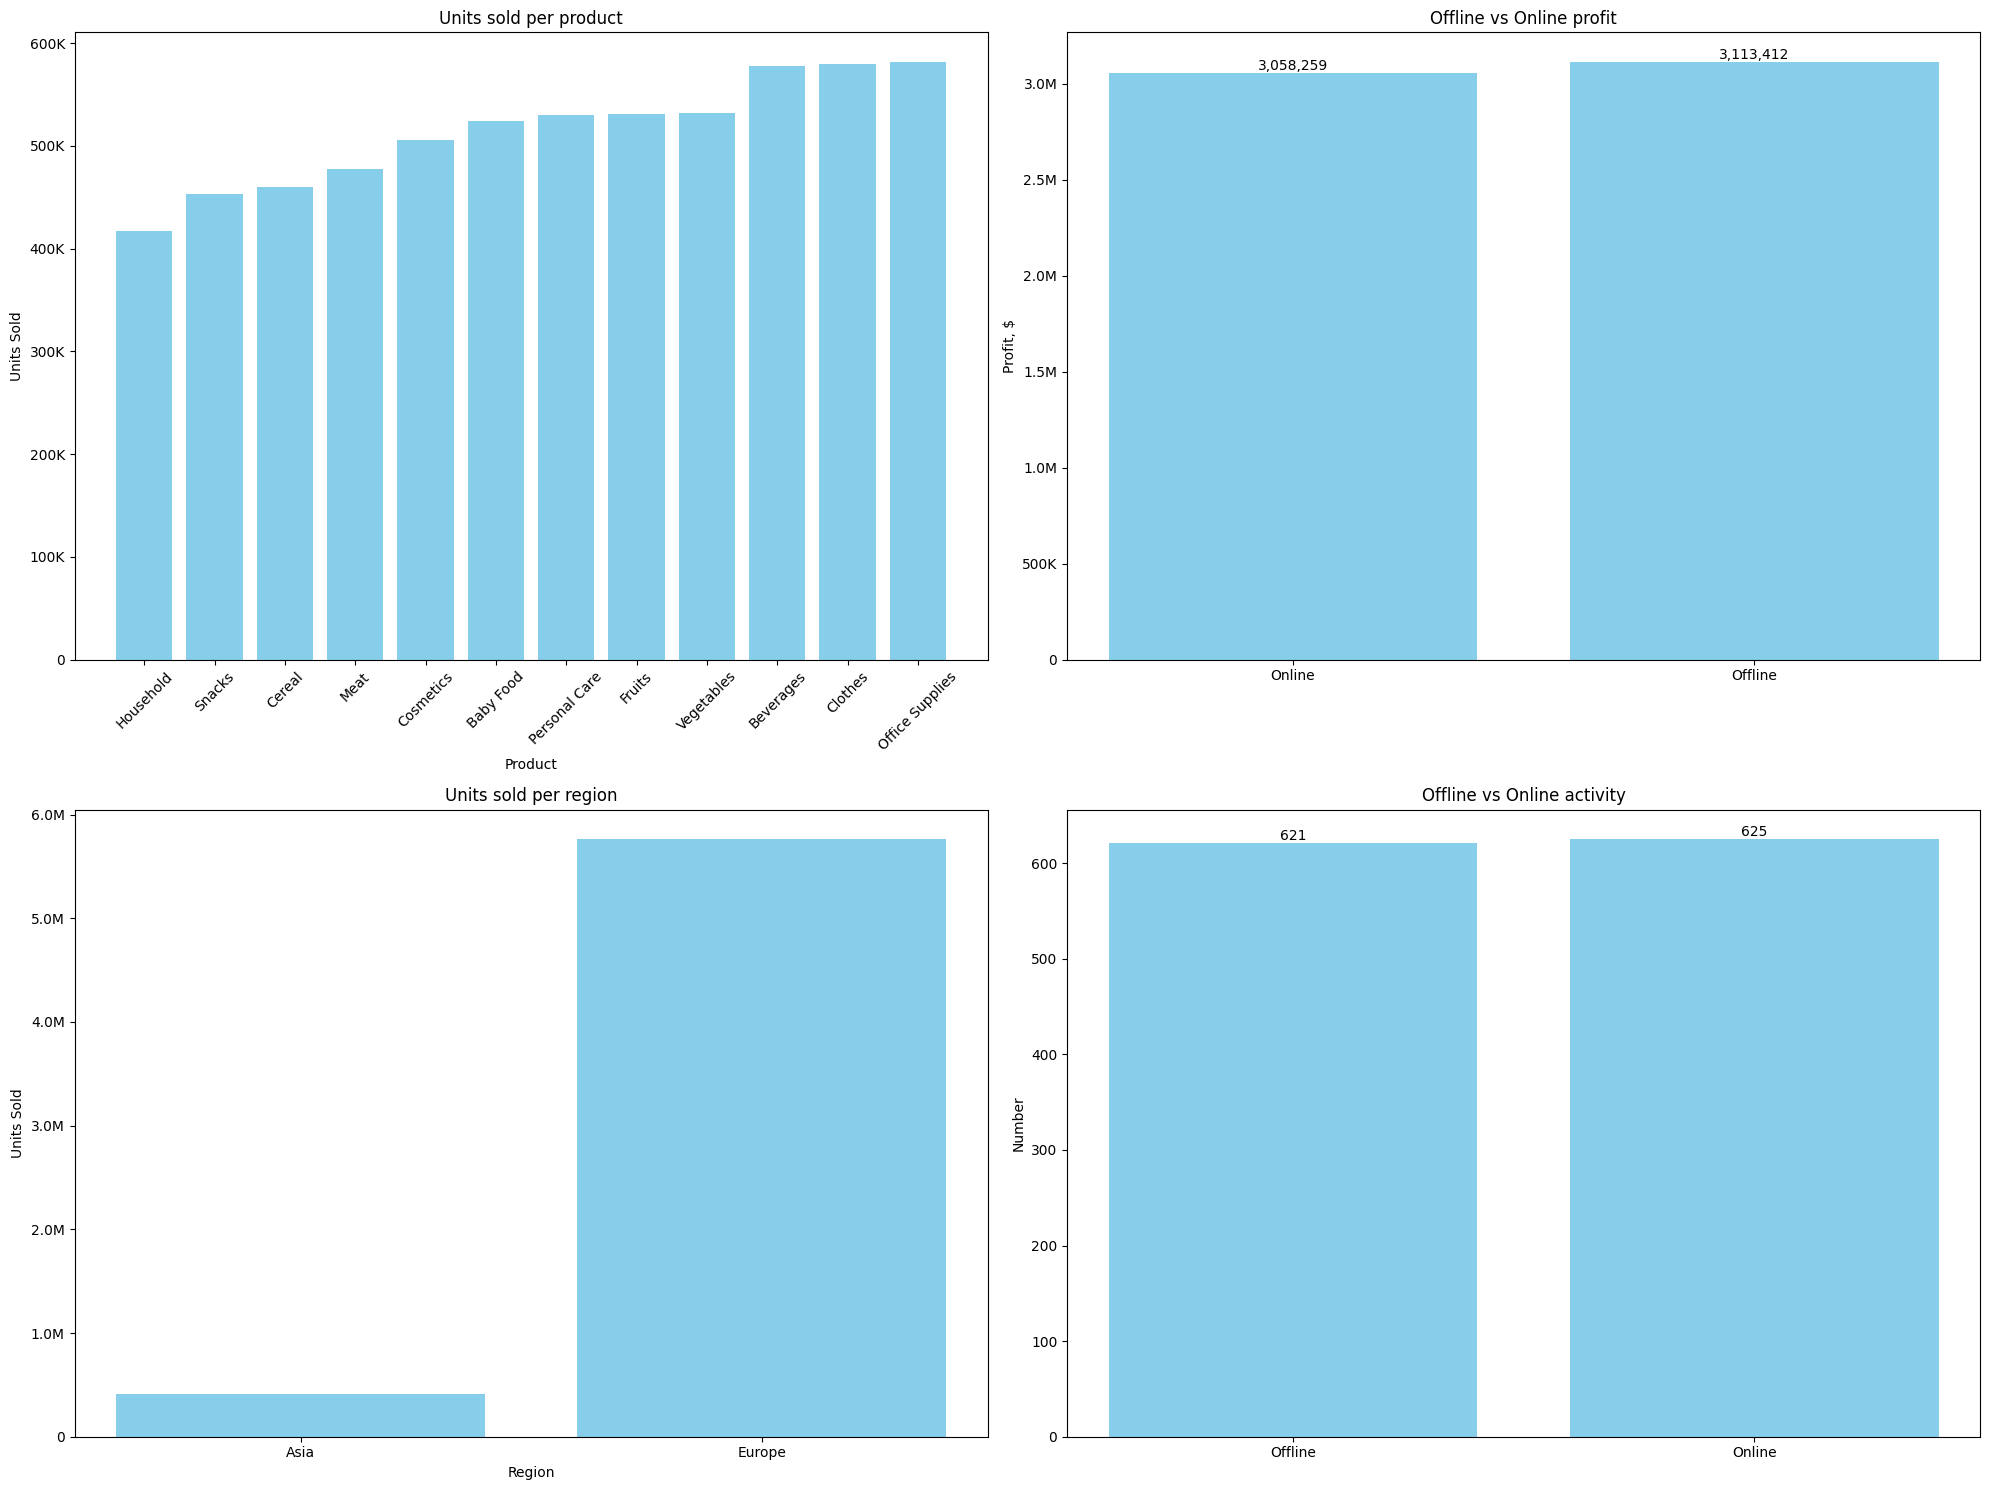

In [ ]:

def human_format(x, pos):
    if x >= 1e6:
        return f'{x/1e6:.1f}M'
    elif x >= 1e3:
        return f'{x/1e3:.0f}K'
    else:
        return f'{int(x)}'


units_per_product = joined.groupby("item_type")["Units Sold"].sum().sort_values()
units_per_region = joined.groupby("region")["Units Sold"].sum().sort_values()
online_offline_profit = joined.groupby("Sales Channel")["Units Sold"].sum().sort_values()
online_offline_count = joined.groupby("Sales Channel")["Units Sold"].count().sort_values()

fig, ax = plt.subplots(2, 2, figsize=(20,15))

# Products
ax[0,0].bar(units_per_product.index, units_per_product.values, color="skyblue")
ax[0,0].set_title("Units sold per product")
ax[0,0].set_xlabel("Product")
ax[0,0].set_ylabel("Units Sold")
ax[0,0].tick_params(axis="x", rotation=45)
ax[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(human_format))

# Profit offline vs online
bars1 = ax[0,1].bar(online_offline_profit.index, online_offline_profit.values, color="skyblue")
ax[0,1].set_title("Offline vs Online profit")
ax[0,1].set_ylabel("Profit, $")
ax[0,1].bar_label(bars1, labels=[f"{int(v):,}" for v in online_offline_profit.values], label_type="edge")
ax[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(human_format))

# Regions
ax[1,0].bar(units_per_region.index, units_per_region.values, color="skyblue")
ax[1,0].set_title("Units sold per region")
ax[1,0].set_xlabel("Region")
ax[1,0].set_ylabel("Units Sold")
ax[1,0].yaxis.set_major_formatter(mticker.FuncFormatter(human_format))

# Activity offline vs online
bars3 = ax[1,1].bar(online_offline_count.index, online_offline_count.values, color="skyblue")
ax[1,1].set_title("Offline vs Online activity")
ax[1,1].set_ylabel("Number")
ax[1,1].bar_label(bars3, labels=[f"{int(v):,}" for v in online_offline_count.values], label_type="edge")
ax[1,1].yaxis.set_major_formatter(mticker.FuncFormatter(human_format))

plt.tight_layout()
plt.show()




Найприбутковішими є категорії Office supplies, Clothes, Beverages.
Household є найзбитковішими.


Відчутної різниці між онлайн і офлайн торгівлею не помічено, як в кількості, так і в доходності.

Регіон Європи значно переважає регіон Азії.


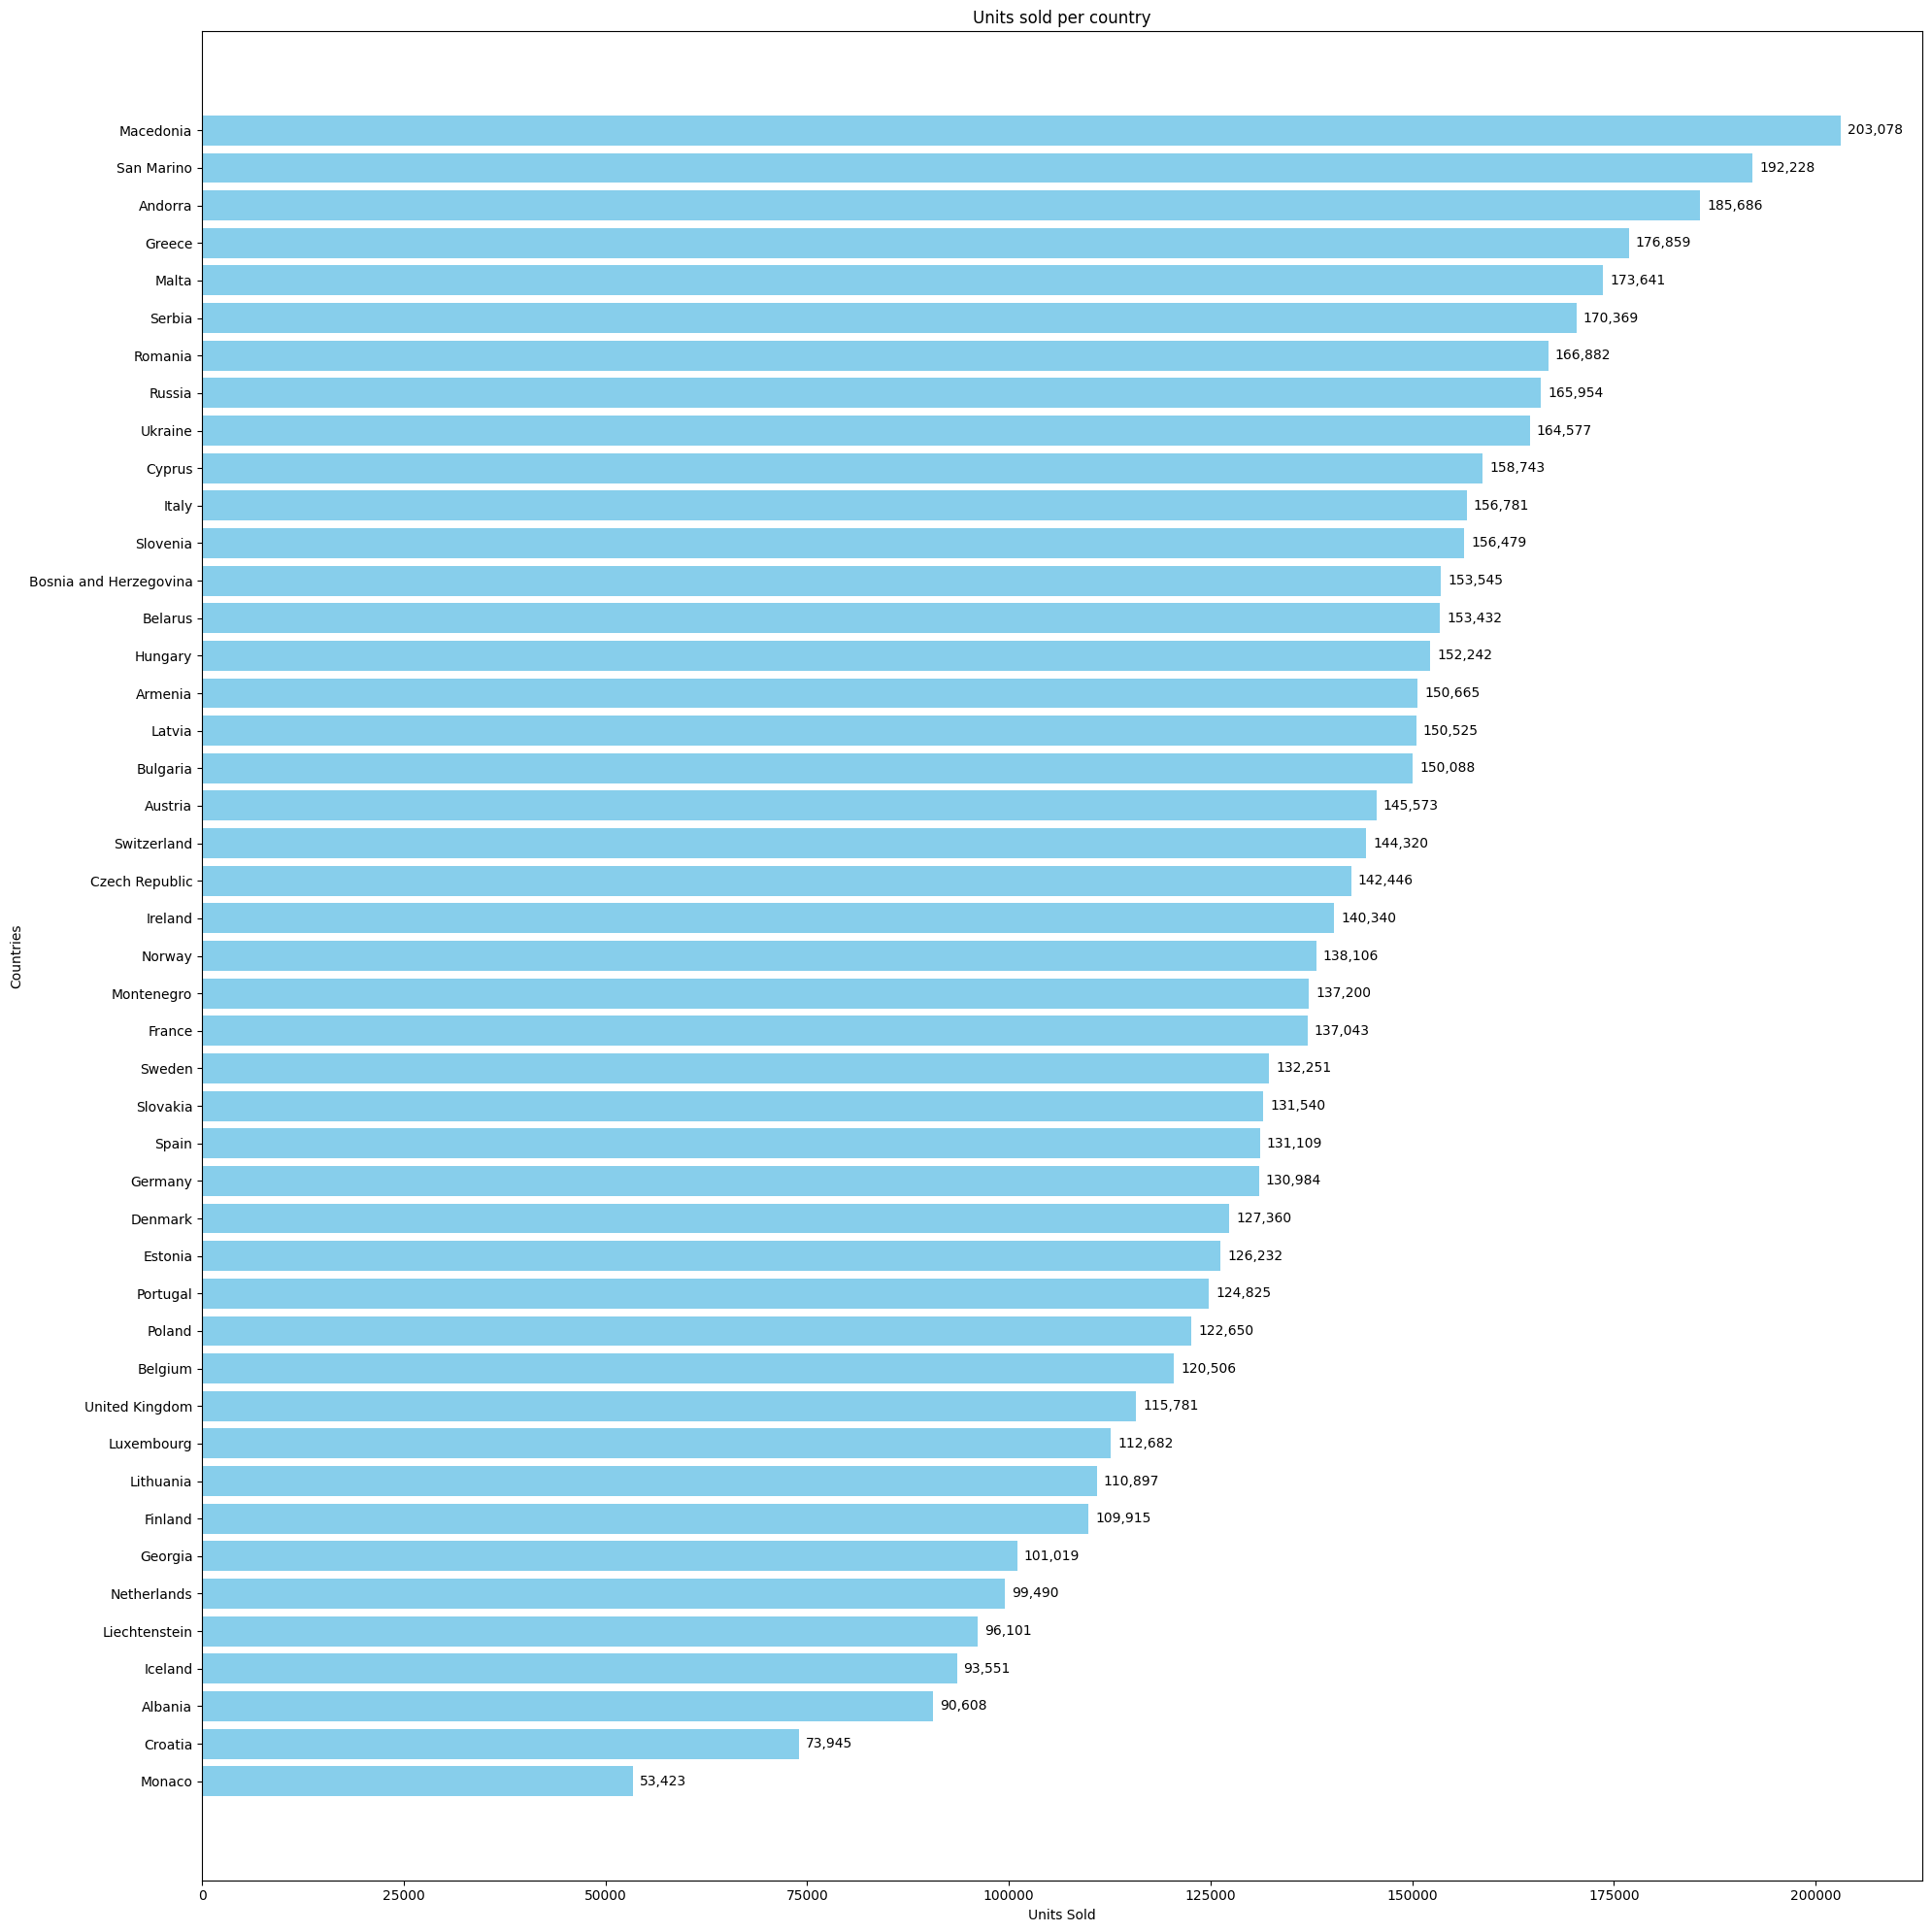

In [ ]:

# countries vs profit
countries_profit = joined.groupby("Country name")["Units Sold"].sum().sort_values()

fig, ax = plt.subplots(figsize=(20,20))

# Horizontal bars
bars = ax.barh(countries_profit.index, countries_profit.values, color="skyblue")

ax.bar_label(bars, labels=[f"{int(v):,}" for v in countries_profit.values], label_type="edge", padding=5)

ax.set_title("Units sold per country")
ax.set_xlabel("Units Sold")
ax.set_ylabel("Countries")

plt.tight_layout()
plt.show()




Топ 3 країни з найбільшою кількістю продаж: Македонія, Сан Маріно і Андорра.
Албанія, Хорватія і Монако мають найгірші показники продажів.

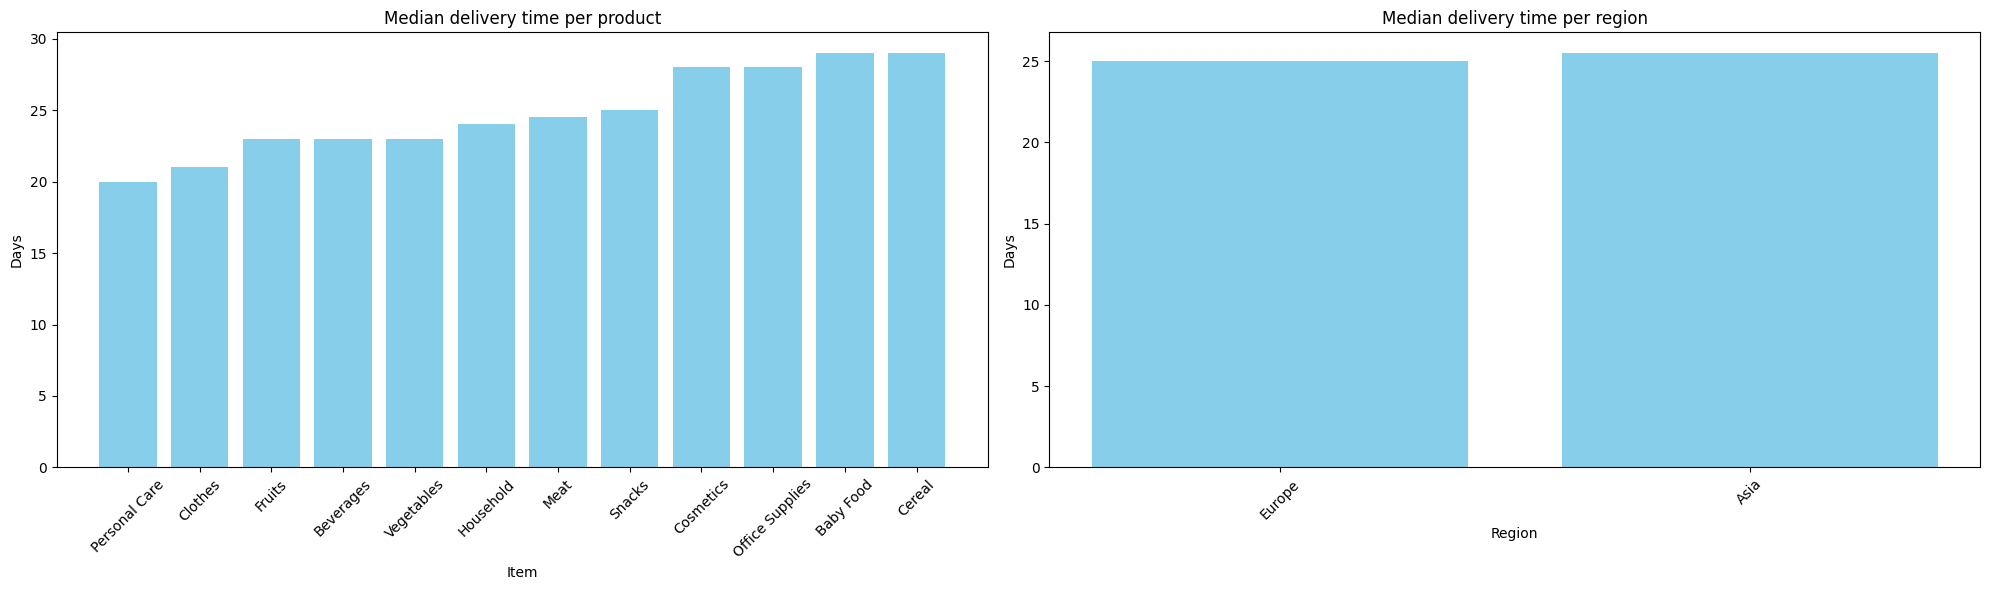

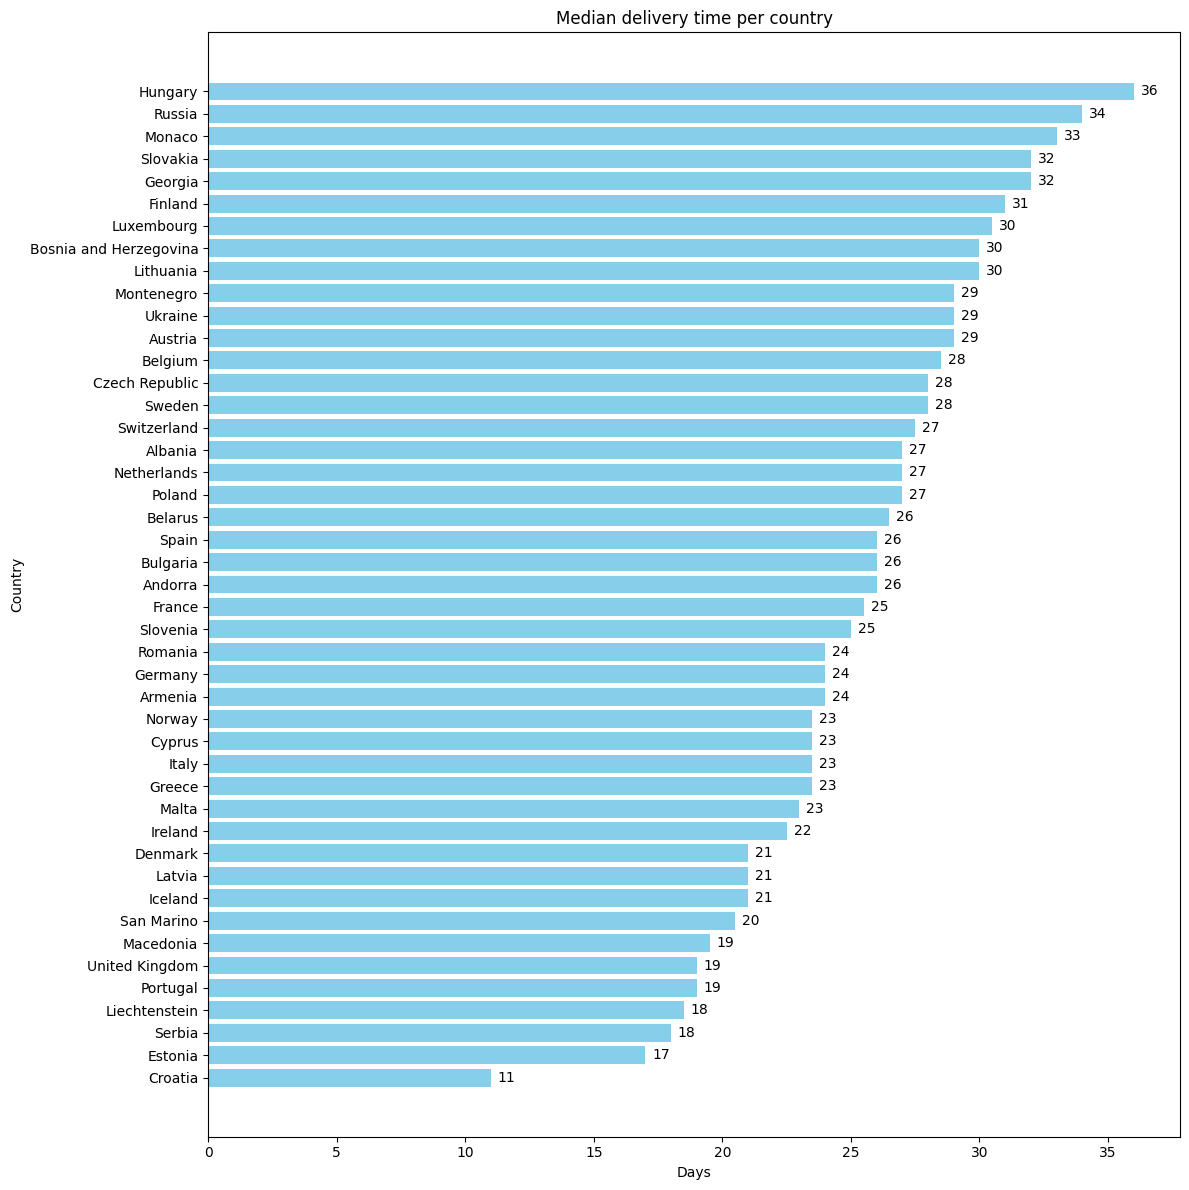

In [ ]:
# Time spent to deliver

joined["Delivery Time"] = joined["Ship Date"] - joined["Order Date"]



median_delivery_item = joined.groupby("item_type")["Delivery Time"].apply(lambda x: x.dt.days.median()).sort_values()

median_delivery_region = joined.groupby("region")["Delivery Time"].apply(lambda x: x.dt.days.median()).sort_values()

median_delivery_countries = joined.groupby("Country name")["Delivery Time"].apply(lambda x: x.dt.days.median()).sort_values()

fig, ax = plt.subplots(1, 2, figsize=(20, 6))

ax[0].bar(median_delivery_item.index, median_delivery_item.values, color="skyblue")
ax[0].set_title("Median delivery time per product")
ax[0].set_xlabel("Item")
ax[0].set_ylabel("Days")
ax[0].tick_params(axis="x", rotation=45)

# Median delivery per region
ax[1].bar(median_delivery_region.index, median_delivery_region.values, color="skyblue")
ax[1].set_title("Median delivery time per region")
ax[1].set_xlabel("Region")
ax[1].set_ylabel("Days")
ax[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 12))

bars = ax.barh(median_delivery_countries.index, median_delivery_countries.values, color="skyblue")
ax.set_title("Median delivery time per country")
ax.set_xlabel("Days")
ax.set_ylabel("Country")

# Підписи значень біля барів
ax.bar_label(bars, labels=[f"{int(v)}" for v in median_delivery_countries.values], label_type="edge", padding=5)

plt.tight_layout()
plt.show()




Показник середнього часу доставки є найгіршим у наступних товарів: Cereal, Baby food.
Найкращий: Personal Care, Clothes.

В розрізі країн найшвидша доставка в Croatia.
Найгірша в Hungary.


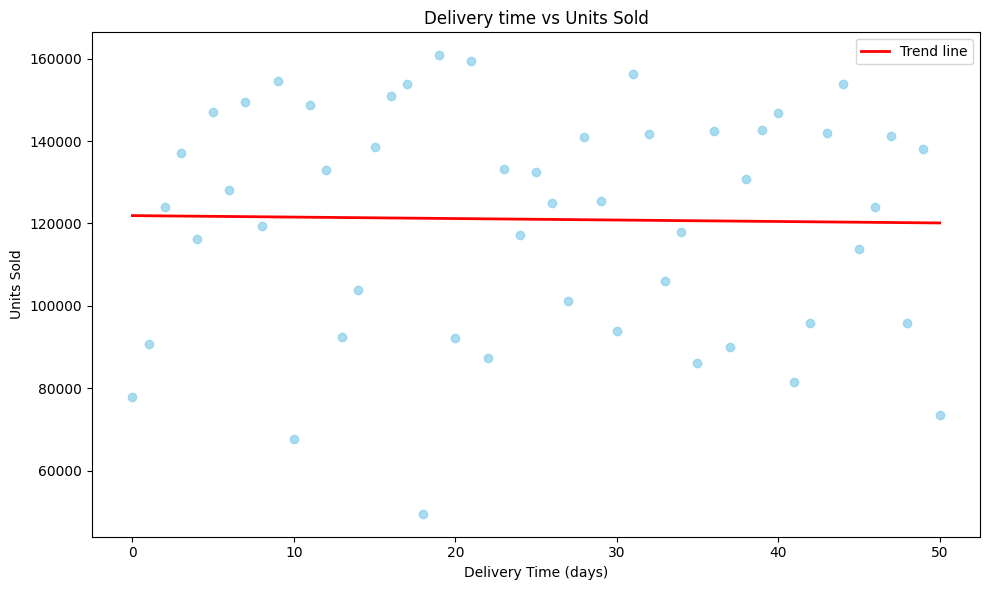

In [ ]:
joined["Delivery Time"] = (joined["Ship Date"] - joined["Order Date"]).dt.days

delivery_profit = joined.groupby("Delivery Time")["Units Sold"].sum()

x = delivery_profit.index
y = delivery_profit.values

fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(x, y, color="skyblue", alpha=0.7)

m, b = np.polyfit(x, y, 1)
ax.plot(x, m*x + b, color="red", linewidth=2, label="Trend line")

ax.set_title("Delivery time vs Units Sold")
ax.set_xlabel("Delivery Time (days)")
ax.set_ylabel("Units Sold")
ax.legend()

plt.tight_layout()
plt.show()



Залежності між кількості продажів і часом доставки немає.

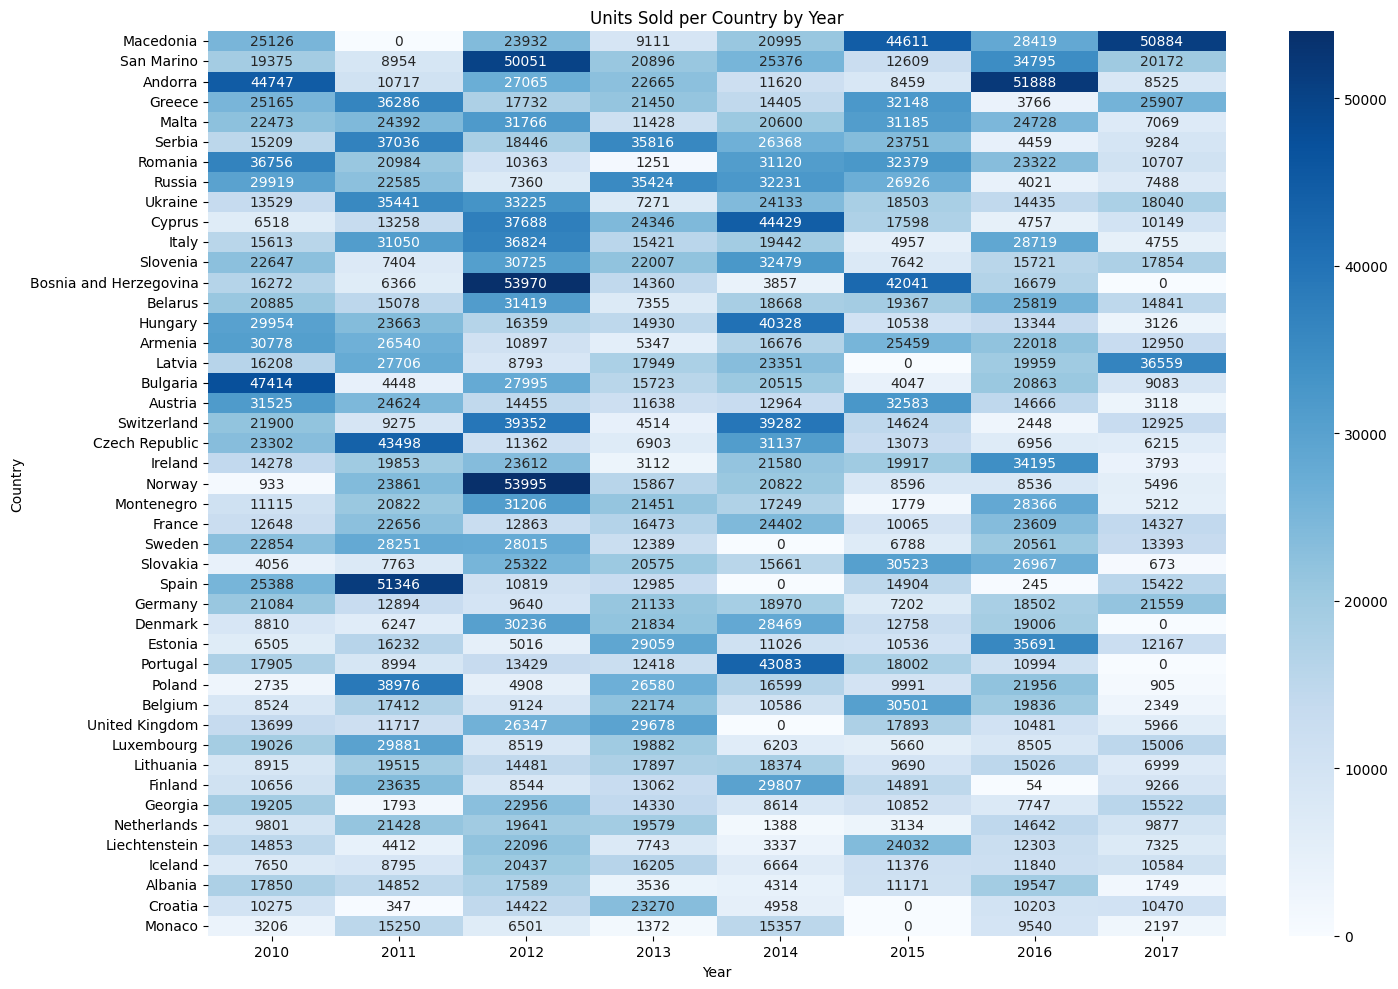

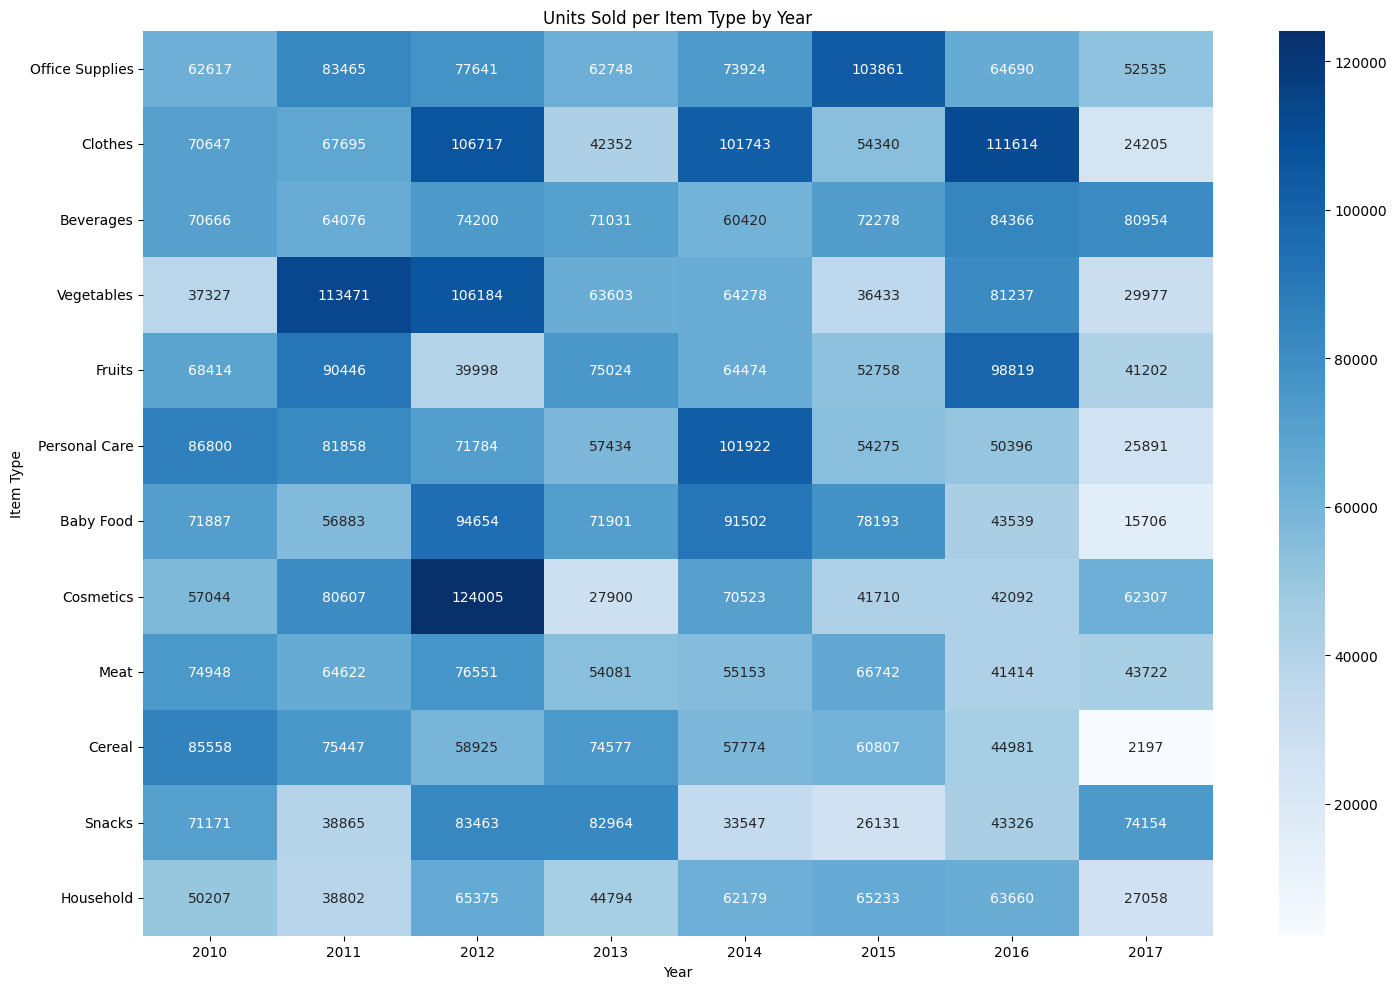

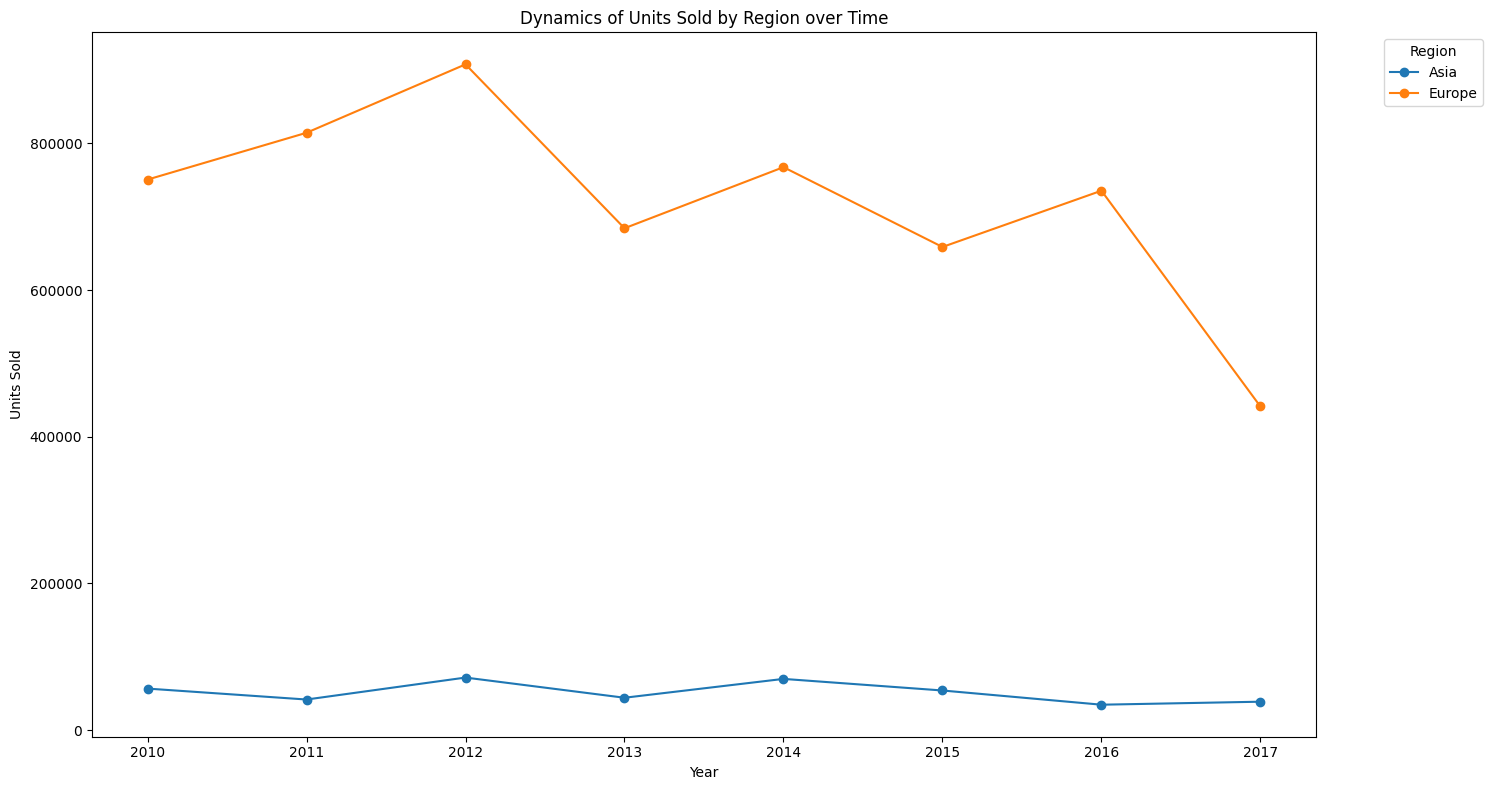

In [ ]:

# Проаналізуй за допомогою візуалізації динаміку продажів (у часі) у розрізі країн категорій товарів, , регіонів, визнач основні тенденції.

pivot = joined.pivot_table(
    index="Country name",
    columns=joined["Order Date"].dt.year,
    values="Units Sold",
    aggfunc="sum"
).fillna(0)

# Сортування країн за сумою продажів (від більшого до меншого)
pivot_sorted = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(15,10))
sns.heatmap(pivot_sorted, cmap="Blues", annot=True, fmt=".0f")
plt.title("Units Sold per Country by Year")
plt.xlabel("Year")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


# Проаналізуй за допомогою візуалізації динаміку продажів (у часі) у розрізі категорій
pivot_items = joined.pivot_table(
    index="item_type",
    columns=joined["Order Date"].dt.year,
    values="Units Sold",
    aggfunc="sum"
).fillna(0)

# Сортування категорій за сумою продажів
pivot_items_sorted = pivot_items.loc[pivot_items.sum(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(15,10))
sns.heatmap(pivot_items_sorted, cmap="Blues", annot=True, fmt=".0f")
plt.title("Units Sold per Item Type by Year")
plt.xlabel("Year")
plt.ylabel("Item Type")
plt.tight_layout()
plt.show()

# Проаналізуй за допомогою візуалізації динаміку продажів (у часі) у розрізі регіонів

sales_region = (
    joined.groupby([joined["Order Date"].dt.year, "region"])["Units Sold"]
    .sum()
    .unstack()
    .fillna(0)
)


plt.figure(figsize=(15,8))
for region in sales_region.columns:
    plt.plot(sales_region.index, sales_region[region], marker="o", label=region)

plt.title("Dynamics of Units Sold by Region over Time")
plt.xlabel("Year")
plt.ylabel("Units Sold")
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


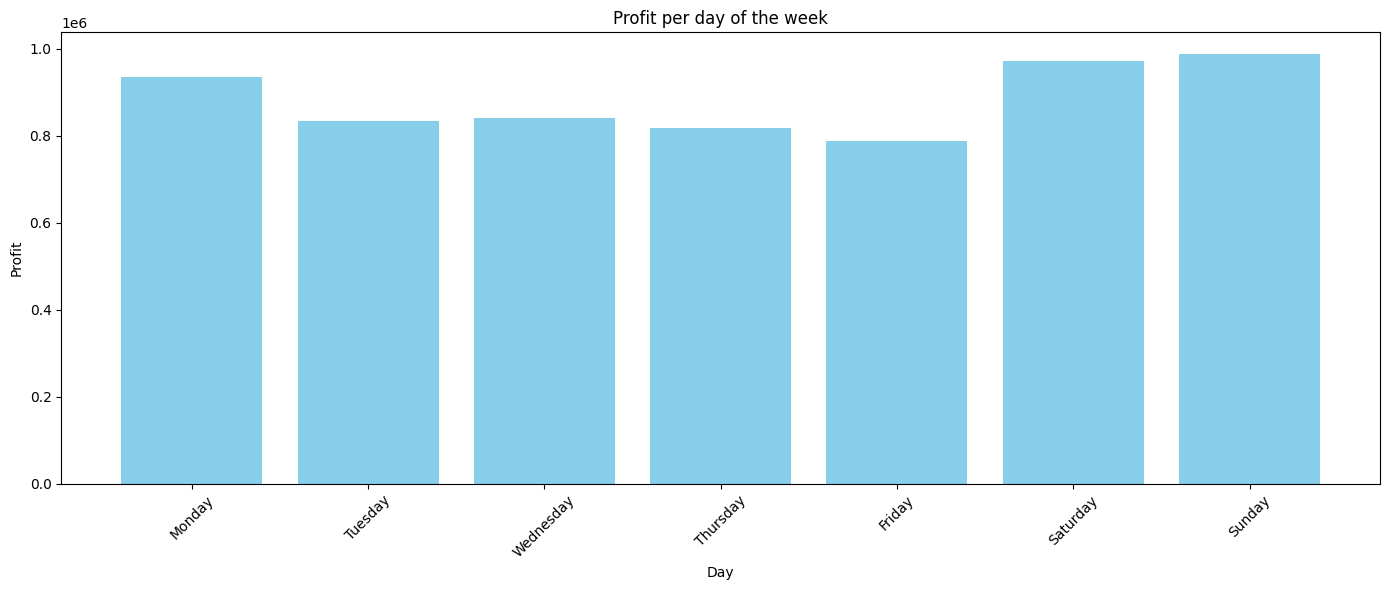

In [ ]:


# Group by year-month

days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

orders_per_day = (
    joined.groupby(joined["Order Date"].dt.day_name())["Units Sold"].sum()
    .reindex(days_order))

# Plot
fig, ax = plt.subplots(figsize=(14,6))
ax.bar(orders_per_day.index.astype(str), orders_per_day.values, color="skyblue")
ax.set_title("Profit per day of the week")
ax.set_xlabel("Day")
ax.set_ylabel("Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()






Висновки:

Загальна ефективність
Аналіз показав, що загальний дохід компанії формують переважно три категорії товарів: Office supplies, Clothes та Beverages. Ці категорії забезпечують найвищу прибутковість і є основними драйверами продажів. Категорія Household демонструє негативну рентабельність і вимагає додаткового розслідування причин збитковості.


Канали збуту
Різниця між онлайн- і офлайн-продажами за обсягами та прибутковістю суттєво не проявляється — обидва канали працюють приблизно рівно. Це може свідчити або про добре збалансовану стратегію каналів, або про те, що різниця прихована в підсегментах (наприклад, за категоріями товарів чи сегментами клієнтів).


Географія
Європейський регіон істотно перевищує Азійський за обсягами продажів. Топ-3 країн за кількістю продажів — Македонія, Сан-Маріно та Андорра; найнижчі показники у Албанії, Хорватії та Монако. Наявність малих країн у топі може вказувати на локальні особливості продажів (акції, локальні партнери або сезонність).


Логістика та час доставки
Найдовший середній час доставки спостерігається для категорій Cereal та Baby food; найшвидша доставка — для Personal Care та Clothes. За країнами найшвидша доставка зафіксована в Croatia, найповільніша — в Hungary. Це вказує на логістичні вузькі місця або різницю в локальних операціях.


Взаємозв’язок часу доставки і продажів
Прямої кореляції між середнім часом доставки та обсягом продажів не виявлено. Це означає, що для покупців зараз важливіші інші фактори (ціна, асортимент, бренд), або вплив часу доставки проявляється в інших метриках (наприклад, у повторних покупках чи рейтингах задоволеності).